<a href="https://colab.research.google.com/github/asomanibernard191-arch/Syntecxhub_House_Price_Prediction/blob/main/Syntecxhub_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Loading the real-world California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Displaying basic info and first few rows
print(f"Dataset Shape: {df.shape}")
df.head()



Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
# Defining features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction and Evaluation
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.5758
RMSE: 0.7456


Model saved successfully as house_price_model.pkl


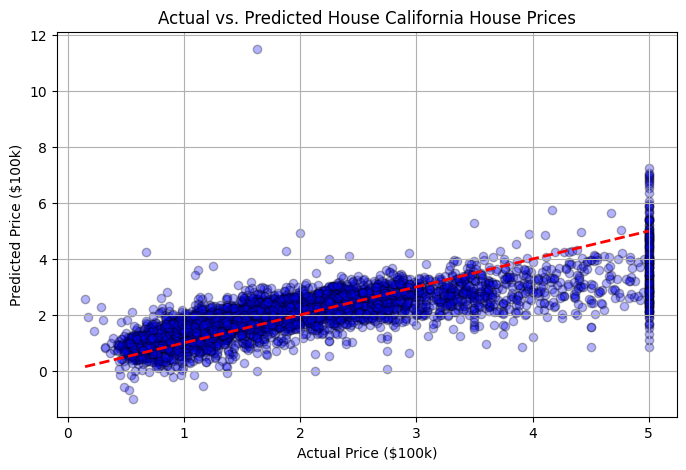

In [10]:
# Saving the trained model on California Housing data using joblib
joblib.dump(model, 'house_price_model.pkl')
print("Model saved successfully as house_price_model.pkl")


# Plotting Actual vs Predicted Prices
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue', edgecolors='k', alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price ($100k)")
plt.ylabel("Predicted Price ($100k)")
plt.title("Actual vs. Predicted House California House Prices")
plt.grid(True)
plt.show()
